In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, CSVLogger
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

PROJECT_DIR = Path("/content/drive/MyDrive/DERİNMODEL")

PROCESSED_DATA_DIR = PROJECT_DIR / "01_veri_seti" / "islenmis_veri"

OUTPUT_DIR = PROJECT_DIR / "03_ciktilar"
GRAPH_DIR = OUTPUT_DIR / "grafikler" / "3_kendi_cnn_modeli"
TABLE_DIR = OUTPUT_DIR / "tablolar"
MODEL_DIR = PROJECT_DIR / "04_modeller" / "kendi_cnn_modeli"

for path in [
    GRAPH_DIR,
    TABLE_DIR,
    MODEL_DIR
]:
    path.mkdir(parents=True, exist_ok=True)

print("Proje klasörü:", PROJECT_DIR)
print("İşlenmiş veri klasörü var mı?:", PROCESSED_DATA_DIR.exists())
print("İşlenmiş veri klasörü:", PROCESSED_DATA_DIR)
print("Model kayıt klasörü:", MODEL_DIR)
print("Grafik kayıt klasörü:", GRAPH_DIR)
print("Tablo kayıt klasörü:", TABLE_DIR)

Proje klasörü: /content/drive/MyDrive/DERİNMODEL
İşlenmiş veri klasörü var mı?: True
İşlenmiş veri klasörü: /content/drive/MyDrive/DERİNMODEL/01_veri_seti/islenmis_veri
Model kayıt klasörü: /content/drive/MyDrive/DERİNMODEL/04_modeller/kendi_cnn_modeli
Grafik kayıt klasörü: /content/drive/MyDrive/DERİNMODEL/03_ciktilar/grafikler/3_kendi_cnn_modeli
Tablo kayıt klasörü: /content/drive/MyDrive/DERİNMODEL/03_ciktilar/tablolar


In [3]:
for split in ["train", "validation", "test"]:
    print(f"\n{split.upper()}")

    split_total = 0

    for class_name in ["kusurlu", "kusursuz"]:
        class_dir = PROCESSED_DATA_DIR / split / class_name
        image_count = len(list(class_dir.glob("*.PNG")))

        split_total += image_count
        print(f"{class_name}: {image_count}")

    print("Toplam:", split_total)


TRAIN
kusurlu: 357
kusursuz: 2403
Toplam: 2760

VALIDATION
kusurlu: 89
kusursuz: 601
Toplam: 690

TEST
kusurlu: 454
kusursuz: 2996
Toplam: 3450


In [4]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 42

train_dir = PROCESSED_DATA_DIR / "train"
val_dir = PROCESSED_DATA_DIR / "validation"
test_dir = PROCESSED_DATA_DIR / "test"

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True,
    seed=SEED
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

class_names = train_dataset.class_names

print("Sınıf sırası:", class_names)
print("Train batch sayısı:", len(train_dataset))
print("Validation batch sayısı:", len(validation_dataset))
print("Test batch sayısı:", len(test_dataset))

Found 2760 files belonging to 2 classes.
Found 690 files belonging to 2 classes.
Found 3450 files belonging to 2 classes.
Sınıf sırası: ['kusurlu', 'kusursuz']
Train batch sayısı: 87
Validation batch sayısı: 22
Test batch sayısı: 108


In [5]:
# Sınıf eşleşmesini kaydetme
class_mapping_df = pd.DataFrame({
    "class_index": list(range(len(class_names))),
    "class_name": class_names
})

class_mapping_path = TABLE_DIR / "dagm_2007_kendi_cnn_class_mapping.csv"
class_mapping_df.to_csv(class_mapping_path, index=False)

print("Sınıf eşleşmesi kaydedildi:")
print(class_mapping_path)
display(class_mapping_df)


# Train etiketlerini toplayarak class_weight hesaplama
train_labels = []

for _, labels in train_dataset:
    train_labels.extend(labels.numpy().reshape(-1).astype(int))

train_labels = np.array(train_labels)

unique_classes = np.unique(train_labels)

class_weights_values = compute_class_weight(
    class_weight="balanced",
    classes=unique_classes,
    y=train_labels
)

class_weight_dict = {
    int(cls): float(weight)
    for cls, weight in zip(unique_classes, class_weights_values)
}

class_weight_df = pd.DataFrame({
    "class_index": list(class_weight_dict.keys()),
    "class_name": [class_names[i] for i in class_weight_dict.keys()],
    "class_weight": list(class_weight_dict.values())
})

class_weight_path = TABLE_DIR / "dagm_2007_kendi_cnn_class_weight.csv"
class_weight_df.to_csv(class_weight_path, index=False)

print("\nClass weight değerleri:")
print(class_weight_dict)

print("\nClass weight tablosu kaydedildi:")
print(class_weight_path)

display(class_weight_df)

Sınıf eşleşmesi kaydedildi:
/content/drive/MyDrive/DERİNMODEL/03_ciktilar/tablolar/dagm_2007_kendi_cnn_class_mapping.csv


,class_index,class_name
0,0,kusurlu
1,1,kusursuz



Class weight değerleri:
{0: 3.865546218487395, 1: 0.5742821473158551}

Class weight tablosu kaydedildi:
/content/drive/MyDrive/DERİNMODEL/03_ciktilar/tablolar/dagm_2007_kendi_cnn_class_weight.csv


,class_index,class_name,class_weight
0,0,kusurlu,3.865546
1,1,kusursuz,0.574282


In [6]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().shuffle(1000, seed=SEED).prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name="data_augmentation")

normalization_layer = layers.Rescaling(1./255, name="normalization")

print("Dataset pipeline hazır.")
print("Normalizasyon model içinde yapılacak: piksel değerleri 0-255 aralığından 0-1 aralığına çekilecek.")
print("Augmentation sadece eğitim sırasında uygulanacak.")

Dataset pipeline hazır.
Normalizasyon model içinde yapılacak: piksel değerleri 0-255 aralığından 0-1 aralığına çekilecek.
Augmentation sadece eğitim sırasında uygulanacak.


In [7]:
INPUT_SHAPE = IMG_SIZE + (3,)

def build_regularized_cnn_model():
    model = models.Sequential([
        layers.Input(shape=INPUT_SHAPE),

        # Normalizasyon modelin içinde
        normalization_layer,

        # Augmentation sadece eğitimde aktif olur
        data_augmentation,

        # 1. Conv blok
        layers.Conv2D(
            16,
            (3, 3),
            padding="same",
            activation="relu",
            kernel_regularizer=regularizers.l2(0.001)
        ),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Dropout(0.20),

        # 2. Conv blok
        layers.Conv2D(
            32,
            (3, 3),
            padding="same",
            activation="relu",
            kernel_regularizer=regularizers.l2(0.001)
        ),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        # 3. Conv blok
        layers.Conv2D(
            64,
            (3, 3),
            padding="same",
            activation="relu",
            kernel_regularizer=regularizers.l2(0.001)
        ),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Dropout(0.30),

        # Flatten yerine GlobalAveragePooling kullanıyoruz
        # Bu, parametre sayısını azaltır ve ezberlemeyi düşürür
        layers.GlobalAveragePooling2D(),

        layers.Dense(
            64,
            activation="relu",
            kernel_regularizer=regularizers.l2(0.001)
        ),
        layers.BatchNormalization(),
        layers.Dropout(0.50),

        layers.Dense(1, activation="sigmoid")
    ], name="DAGM_Regularized_Custom_CNN")

    return model


model = build_regularized_cnn_model()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

model.summary()

Model: "DAGM_Regularized_Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Rescaling)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,513 (111.38 KB)

 Trainable params: 28,161 (110.00 KB)

 Non-trainable params: 352 (1.38 KB)

In [8]:
model_path = MODEL_DIR / "dagm_2007_kendi_cnn_regularized_best_model.keras"

checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=str(model_path),
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1
)

early_stopping_callback = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_callback = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

csv_logger_callback = tf.keras.callbacks.CSVLogger(
    str(TABLE_DIR / "dagm_2007_kendi_cnn_training_log.csv")
)

print("Callback ayarları hazır.")
print("En iyi model kayıt yolu:", model_path)

Callback ayarları hazır.
En iyi model kayıt yolu: /content/drive/MyDrive/DERİNMODEL/04_modeller/kendi_cnn_modeli/dagm_2007_kendi_cnn_regularized_best_model.keras


In [10]:
EPOCHS = 30

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=[
        checkpoint_callback,
        early_stopping_callback,
        reduce_lr_callback,
        csv_logger_callback
    ],
    verbose=1
)

print("Kendi CNN model eğitimi tamamlandı.")
print("En iyi model kayıt yolu:")
print(model_path)

Epoch 1/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.4840 - loss: 1.0398 - precision: 0.8632 - recall: 0.4840
Epoch 1: val_loss improved from None to 0.82527, saving model to /content/drive/MyDrive/DERİNMODEL/04_modeller/kendi_cnn_modeli/dagm_2007_kendi_cnn_regularized_best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/DERİNMODEL/04_modeller/kendi_cnn_modeli/dagm_2007_kendi_cnn_regularized_best_model.keras
87/87 ━━━━━━━━━━━━━━━━━━━━ 195s 2s/step - accuracy: 0.5011 - loss: 0.9889 - precision: 0.8783 - recall: 0.4956 - val_accuracy: 0.4087 - val_loss: 0.8253 - val_precision: 0.8876 - val_recall: 0.3677 - learning_rate: 3.0000e-04
Epoch 2/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5039 - loss: 0.9865 - precision: 0.8746 - recall: 0.5062
Epoch 2: val_loss did not improve from 0.82527
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.5188 - loss: 0.9954 - precision: 0.8730 - recall: 0.5235 - val_accuracy: 0.2522 - val_loss: 1.0040 - val_

In [11]:
test_results = model.evaluate(test_dataset, verbose=1)

print("Kendi CNN test sonuçları")
print("------------------------")
print("Test Loss:", test_results[0])
print("Test Accuracy:", test_results[1])
print("Test Precision:", test_results[2])
print("Test Recall:", test_results[3])

108/108 ━━━━━━━━━━━━━━━━━━━━ 828s 8s/step - accuracy: 0.8661 - loss: 0.5403 - precision: 0.8830 - recall: 0.9750
Kendi CNN test sonuçları
------------------------
Test Loss: 0.5403333306312561
Test Accuracy: 0.8660869598388672
Test Precision: 0.8830108642578125
Test Recall: 0.9749666452407837


108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step
Sınıf sırası: ['kusurlu', 'kusursuz']
Gerçek etiket sayısı: 3450
Tahmin sayısı: 3450
Confusion Matrix:
[[  67  387]
 [  75 2921]]

Classification report kaydedildi:
/content/drive/MyDrive/DERİNMODEL/03_ciktilar/tablolar/dagm_2007_kendi_cnn_classification_report.csv


,precision,recall,f1-score,support
kusurlu,0.471831,0.147577,0.224832,454.000000
kusursuz,0.883011,0.974967,0.926713,2996.000000
accuracy,0.866087,0.866087,0.866087,0.866087
macro avg,0.677421,0.561272,0.575773,3450.000000
weighted avg,0.828902,0.866087,0.834350,3450.000000


<Figure size 600x500 with 0 Axes>

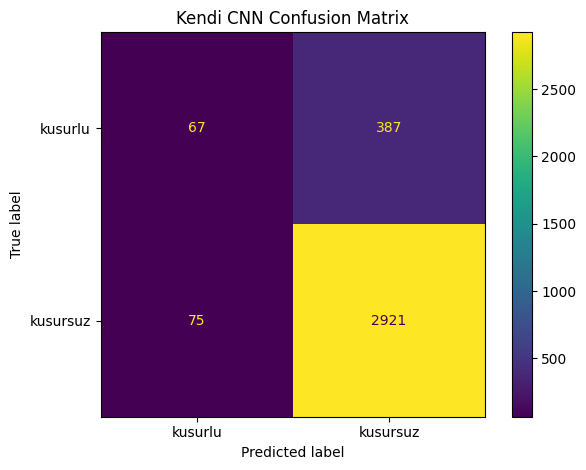

Confusion matrix grafiği kaydedildi:
/content/drive/MyDrive/DERİNMODEL/03_ciktilar/grafikler/3_kendi_cnn_modeli/3_kendi_cnn_modeli/dagm_2007_kendi_cnn_confusion_matrix.png


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Test gerçek etiketleri
y_true = np.concatenate([y.numpy() for x, y in test_dataset], axis=0).astype(int)

# Model olasılık tahminleri
y_prob = model.predict(test_dataset, verbose=1).ravel()

# 0.5 eşik değeri ile sınıf tahmini
y_pred = (y_prob >= 0.5).astype(int)

print("Sınıf sırası:", class_names)
print("Gerçek etiket sayısı:", len(y_true))
print("Tahmin sayısı:", len(y_pred))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_path = TABLE_DIR / "dagm_2007_kendi_cnn_classification_report.csv"
report_df.to_csv(report_path)

print("\nClassification report kaydedildi:")
print(report_path)

display(report_df)

# Confusion matrix grafiği
plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(values_format="d")
plt.title("Kendi CNN Confusion Matrix")
plt.tight_layout()

cm_path = GRAPH_DIR / "3_kendi_cnn_modeli" / "dagm_2007_kendi_cnn_confusion_matrix.png"
cm_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(cm_path, dpi=300)
plt.show()

print("Confusion matrix grafiği kaydedildi:")
print(cm_path)

In [13]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import pandas as pd
import numpy as np

# class_names = ['kusurlu', 'kusursuz']
# y_prob: modelin sigmoid çıktısı, class 1 yani kusursuz olasılığı gibi düşünülüyor
# kusurlu tahmini için: y_prob < threshold

threshold_results = []

for threshold in np.arange(0.05, 0.96, 0.05):
    # y_prob threshold altındaysa kusurlu(0), üstündeyse kusursuz(1)
    y_pred_thr = (y_prob >= threshold).astype(int)

    acc = accuracy_score(y_true, y_pred_thr)

    kusurlu_precision = precision_score(y_true, y_pred_thr, pos_label=0, zero_division=0)
    kusurlu_recall = recall_score(y_true, y_pred_thr, pos_label=0, zero_division=0)
    kusurlu_f1 = f1_score(y_true, y_pred_thr, pos_label=0, zero_division=0)

    kusursuz_precision = precision_score(y_true, y_pred_thr, pos_label=1, zero_division=0)
    kusursuz_recall = recall_score(y_true, y_pred_thr, pos_label=1, zero_division=0)
    kusursuz_f1 = f1_score(y_true, y_pred_thr, pos_label=1, zero_division=0)

    threshold_results.append({
        "threshold": round(threshold, 2),
        "accuracy": acc,
        "kusurlu_precision": kusurlu_precision,
        "kusurlu_recall": kusurlu_recall,
        "kusurlu_f1": kusurlu_f1,
        "kusursuz_precision": kusursuz_precision,
        "kusursuz_recall": kusursuz_recall,
        "kusursuz_f1": kusursuz_f1
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_path = TABLE_DIR / "dagm_2007_kendi_cnn_threshold_analizi.csv"
threshold_df.to_csv(threshold_path, index=False)

print("Threshold analiz tablosu kaydedildi:")
print(threshold_path)

display(threshold_df)

Threshold analiz tablosu kaydedildi:
/content/drive/MyDrive/DERİNMODEL/03_ciktilar/tablolar/dagm_2007_kendi_cnn_threshold_analizi.csv


,threshold,accuracy,kusurlu_precision,kusurlu_recall,kusurlu_f1,kusursuz_precision,kusursuz_recall,kusursuz_f1
0,0.05,0.885217,1.000000,0.127753,0.226562,0.883255,1.000000,0.938009
1,0.10,0.886087,0.929577,0.145374,0.251429,0.885173,0.998331,0.938353
2,0.15,0.885217,0.891892,0.145374,0.250000,0.885071,0.997330,0.937853
3,0.20,0.884058,0.846154,0.145374,0.248120,0.884935,0.995995,0.937186
4,0.25,0.881449,0.752809,0.147577,0.246777,0.884856,0.992657,0.935661
5,0.30,0.878551,0.676768,0.147577,0.242315,0.884512,0.989319,0.933985
6,0.35,0.873623,0.577586,0.147577,0.235088,0.883923,0.983645,0.931122
7,0.40,0.871304,0.540323,0.147577,0.231834,0.883644,0.980975,0.929769
8,0.45,0.868696,0.503759,0.147577,0.228279,0.883328,0.977971,0.928243
9,0.50,0.866087,0.471831,0.147577,0.224832,0.883011,0.974967,0.926713


## 4. Dengeli Eğitim Stratejisi ile İkinci Kendi CNN Modeli

İlk kendi CNN modelinde test accuracy yüksek görünmesine rağmen confusion matrix incelendiğinde kusurlu sınıfın yeterince iyi yakalanamadığı görülmüştür. Bu nedenle ikinci aşamada kusurlu sınıfı daha iyi öğrenebilmek için dengeli eğitim stratejisi uygulanmıştır. Bu modelde kusurlu sınıf pozitif sınıf olarak ele alınmıştır.

In [14]:
from pathlib import Path
import tensorflow as tf
import numpy as np
import pandas as pd
import math

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

TRAIN_DIR = PROCESSED_DATA_DIR / "train"
VAL_DIR = PROCESSED_DATA_DIR / "validation"
TEST_DIR = PROCESSED_DATA_DIR / "test"

print("Train klasörü:", TRAIN_DIR)
print("Validation klasörü:", VAL_DIR)
print("Test klasörü:", TEST_DIR)

print("Train var mı?", TRAIN_DIR.exists())
print("Validation var mı?", VAL_DIR.exists())
print("Test var mı?", TEST_DIR.exists())

Train klasörü: /content/drive/MyDrive/DERİNMODEL/01_veri_seti/islenmis_veri/train
Validation klasörü: /content/drive/MyDrive/DERİNMODEL/01_veri_seti/islenmis_veri/validation
Test klasörü: /content/drive/MyDrive/DERİNMODEL/01_veri_seti/islenmis_veri/test
Train var mı? True
Validation var mı? True
Test var mı? True


In [15]:
def load_image_binary_label(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    return image, tf.cast(label, tf.float32)


train_kusurlu_files = sorted(list((TRAIN_DIR / "kusurlu").glob("*.PNG")))
train_kusursuz_files = sorted(list((TRAIN_DIR / "kusursuz").glob("*.PNG")))

val_kusurlu_files = sorted(list((VAL_DIR / "kusurlu").glob("*.PNG")))
val_kusursuz_files = sorted(list((VAL_DIR / "kusursuz").glob("*.PNG")))

test_kusurlu_files = sorted(list((TEST_DIR / "kusurlu").glob("*.PNG")))
test_kusursuz_files = sorted(list((TEST_DIR / "kusursuz").glob("*.PNG")))

print("Train kusurlu:", len(train_kusurlu_files))
print("Train kusursuz:", len(train_kusursuz_files))
print("Validation kusurlu:", len(val_kusurlu_files))
print("Validation kusursuz:", len(val_kusursuz_files))
print("Test kusurlu:", len(test_kusurlu_files))
print("Test kusursuz:", len(test_kusursuz_files))

Train kusurlu: 357
Train kusursuz: 2403
Validation kusurlu: 89
Validation kusursuz: 601
Test kusurlu: 454
Test kusursuz: 2996


In [16]:
# Kusurlu = 1
# Kusursuz = 0

def make_dataset_from_files(file_list, label, shuffle=True):
    paths = [str(p) for p in file_list]
    labels = [label] * len(paths)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=42, reshuffle_each_iteration=True)

    ds = ds.map(load_image_binary_label, num_parallel_calls=AUTOTUNE)
    return ds


# Train için ayrı ayrı dataset oluşturuyoruz
train_kusurlu_ds = make_dataset_from_files(train_kusurlu_files, label=1, shuffle=True)
train_kusursuz_ds = make_dataset_from_files(train_kusursuz_files, label=0, shuffle=True)

# Dengeli örnekleme:
# Her batch içinde kusurlu ve kusursuz görseller daha dengeli gelsin diye iki sınıftan eşit olasılıkla seçiyoruz.
balanced_train_dataset = tf.data.Dataset.sample_from_datasets(
    [train_kusurlu_ds.repeat(), train_kusursuz_ds.repeat()],
    weights=[0.5, 0.5],
    seed=42
)

balanced_train_dataset = balanced_train_dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Validation ve test orijinal dağılımıyla kalacak
val_files = val_kusurlu_files + val_kusursuz_files
val_labels = [1] * len(val_kusurlu_files) + [0] * len(val_kusursuz_files)

test_files = test_kusurlu_files + test_kusursuz_files
test_labels = [1] * len(test_kusurlu_files) + [0] * len(test_kusursuz_files)

validation_dataset_2 = tf.data.Dataset.from_tensor_slices(
    ([str(p) for p in val_files], val_labels)
)
validation_dataset_2 = validation_dataset_2.map(load_image_binary_label, num_parallel_calls=AUTOTUNE)
validation_dataset_2 = validation_dataset_2.batch(BATCH_SIZE).prefetch(AUTOTUNE)

test_dataset_2 = tf.data.Dataset.from_tensor_slices(
    ([str(p) for p in test_files], test_labels)
)
test_dataset_2 = test_dataset_2.map(load_image_binary_label, num_parallel_calls=AUTOTUNE)
test_dataset_2 = test_dataset_2.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Train dataset sonsuz repeat olduğu için kaç adım çalışacağını biz belirliyoruz.
# 1 epoch içinde yaklaşık orijinal train toplamı kadar örnek görecek.
STEPS_PER_EPOCH = math.ceil((len(train_kusurlu_files) + len(train_kusursuz_files)) / BATCH_SIZE)

VALIDATION_STEPS = math.ceil((len(val_kusurlu_files) + len(val_kusursuz_files)) / BATCH_SIZE)

print("Dengeli train dataset hazır.")
print("Validation dataset hazır.")
print("Test dataset hazır.")
print("Steps per epoch:", STEPS_PER_EPOCH)
print("Validation steps:", VALIDATION_STEPS)

Dengeli train dataset hazır.
Validation dataset hazır.
Test dataset hazır.
Steps per epoch: 87
Validation steps: 22


In [17]:
# Dengeli train dataset içinden birkaç batch kontrol edelim

for images, labels in balanced_train_dataset.take(3):
    labels_np = labels.numpy()
    print("Batch label dağılımı:")
    print("kusursuz(0):", np.sum(labels_np == 0))
    print("kusurlu(1):", np.sum(labels_np == 1))
    print("Görüntü batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("-" * 30)

Batch label dağılımı:
kusursuz(0): 22
kusurlu(1): 10
Görüntü batch shape: (32, 128, 128, 3)
Label batch shape: (32,)
------------------------------
Batch label dağılımı:
kusursuz(0): 19
kusurlu(1): 13
Görüntü batch shape: (32, 128, 128, 3)
Label batch shape: (32,)
------------------------------
Batch label dağılımı:
kusursuz(0): 15
kusurlu(1): 17
Görüntü batch shape: (32, 128, 128, 3)
Label batch shape: (32,)
------------------------------


In [18]:
from tensorflow.keras import layers, models, regularizers

INPUT_SHAPE = IMG_SIZE + (3,)

# Sadece train sırasında aktif olacak augmentation
data_augmentation_2 = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name="data_augmentation_2")


def build_balanced_cnn_model():
    model = models.Sequential([
        layers.Input(shape=INPUT_SHAPE),

        # Normalizasyon: 0-255 piksel değerlerini 0-1 aralığına çeker
        layers.Rescaling(1./255),

        # Sadece eğitim sırasında aktif olur
        data_augmentation_2,

        # 1. Conv blok
        layers.Conv2D(
            16,
            (3, 3),
            padding="same",
            activation="relu",
            kernel_regularizer=regularizers.l2(0.001)
        ),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Dropout(0.20),

        # 2. Conv blok
        layers.Conv2D(
            32,
            (3, 3),
            padding="same",
            activation="relu",
            kernel_regularizer=regularizers.l2(0.001)
        ),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        # 3. Conv blok
        layers.Conv2D(
            64,
            (3, 3),
            padding="same",
            activation="relu",
            kernel_regularizer=regularizers.l2(0.001)
        ),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Dropout(0.30),

        layers.GlobalAveragePooling2D(),

        layers.Dense(
            64,
            activation="relu",
            kernel_regularizer=regularizers.l2(0.001)
        ),
        layers.BatchNormalization(),
        layers.Dropout(0.50),

        # Çıkış: kusurlu olma olasılığı
        layers.Dense(1, activation="sigmoid")
    ], name="DAGM_Balanced_Custom_CNN")

    return model


balanced_model = build_balanced_cnn_model()

balanced_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

balanced_model.summary()

Model: "DAGM_Balanced_Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation_2             │ (None, 128, 128, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128, 128, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,513 (111.38 KB)

 Trainable params: 28,161 (110.00 KB)

 Non-trainable params: 352 (1.38 KB)

In [19]:
# İkinci model için kayıt yolları

balanced_model_path = MODEL_DIR / "kendi_cnn_modeli" / "dagm_2007_balanced_cnn_best_model.keras"
balanced_log_path = TABLE_DIR / "dagm_2007_balanced_cnn_training_log.csv"

balanced_model_path.parent.mkdir(parents=True, exist_ok=True)

balanced_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=str(balanced_model_path),
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1
)

balanced_early_stopping_callback = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
    verbose=1
)

balanced_reduce_lr_callback = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

balanced_csv_logger_callback = tf.keras.callbacks.CSVLogger(
    str(balanced_log_path)
)

print("İkinci model callback ayarları hazır.")
print("En iyi model kayıt yolu:", balanced_model_path)
print("Eğitim log kayıt yolu:", balanced_log_path)

İkinci model callback ayarları hazır.
En iyi model kayıt yolu: /content/drive/MyDrive/DERİNMODEL/04_modeller/kendi_cnn_modeli/kendi_cnn_modeli/dagm_2007_balanced_cnn_best_model.keras
Eğitim log kayıt yolu: /content/drive/MyDrive/DERİNMODEL/03_ciktilar/tablolar/dagm_2007_balanced_cnn_training_log.csv


In [20]:
EPOCHS = 30

balanced_history = balanced_model.fit(
    balanced_train_dataset,
    validation_data=validation_dataset_2,
    epochs=EPOCHS,
    steps_per_epoch=STEPS_PER_EPOCH,
    validation_steps=VALIDATION_STEPS,
    callbacks=[
        balanced_checkpoint_callback,
        balanced_early_stopping_callback,
        balanced_reduce_lr_callback,
        balanced_csv_logger_callback
    ],
    verbose=1
)

print("Dengeli ikinci CNN model eğitimi tamamlandı.")
print("En iyi model kayıt yolu:")
print(balanced_model_path)

Epoch 1/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - accuracy: 0.4967 - auc: 0.4921 - loss: 1.0102 - precision: 0.4926 - recall: 0.4745
Epoch 1: val_loss improved from None to 0.94672, saving model to /content/drive/MyDrive/DERİNMODEL/04_modeller/kendi_cnn_modeli/kendi_cnn_modeli/dagm_2007_balanced_cnn_best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/DERİNMODEL/04_modeller/kendi_cnn_modeli/kendi_cnn_modeli/dagm_2007_balanced_cnn_best_model.keras
87/87 ━━━━━━━━━━━━━━━━━━━━ 30s 234ms/step - accuracy: 0.5014 - auc: 0.5034 - loss: 0.9704 - precision: 0.5138 - recall: 0.4849 - val_accuracy: 0.1290 - val_auc: 0.5002 - val_loss: 0.9467 - val_precision: 0.1290 - val_recall: 1.0000 - learning_rate: 3.0000e-04
Epoch 2/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.4923 - auc: 0.5026 - loss: 0.9647 - precision: 0.4939 - recall: 0.4896
Epoch 2: val_loss did not improve from 0.94672
87/87 ━━━━━━━━━━━━━━━━━━━━ 20s 235ms/step - accuracy: 0.5004 - auc: 0.5055 - lo

In [21]:
# En iyi kaydedilen dengeli modeli yükleyelim
best_balanced_model = tf.keras.models.load_model(balanced_model_path)

# Test setinde değerlendirme
balanced_test_results = best_balanced_model.evaluate(test_dataset_2, verbose=1)

print("Dengeli CNN test sonuçları")
print("-------------------------")
print("Test Loss:", balanced_test_results[0])
print("Test Accuracy:", balanced_test_results[1])
print("Test Precision:", balanced_test_results[2])
print("Test Recall:", balanced_test_results[3])
print("Test AUC:", balanced_test_results[4])

108/108 ━━━━━━━━━━━━━━━━━━━━ 22s 174ms/step - accuracy: 0.8843 - auc: 0.6250 - loss: 0.5257 - precision: 0.8986 - recall: 0.1366
Dengeli CNN test sonuçları
-------------------------
Test Loss: 0.5257378220558167
Test Accuracy: 0.8843477964401245
Test Precision: 0.8985507488250732
Test Recall: 0.13656388223171234
Test AUC: 0.6249561905860901


108/108 ━━━━━━━━━━━━━━━━━━━━ 25s 225ms/step
Gerçek etiket sayısı: 3450
Tahmin sayısı: 3450
Confusion Matrix:
[[2989    7]
 [ 392   62]]
Classification report kaydedildi:
/content/drive/MyDrive/DERİNMODEL/03_ciktilar/tablolar/dagm_2007_balanced_cnn_classification_report.csv


,precision,recall,f1-score,support
kusursuz,0.884058,0.997664,0.937431,2996.000000
kusurlu,0.898551,0.136564,0.237094,454.000000
accuracy,0.884348,0.884348,0.884348,0.884348
macro avg,0.891304,0.567114,0.587263,3450.000000
weighted avg,0.885965,0.884348,0.845271,3450.000000


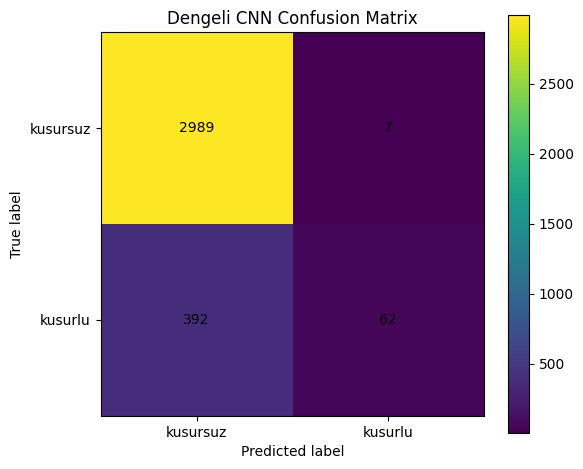

Confusion matrix grafiği kaydedildi:
/content/drive/MyDrive/DERİNMODEL/03_ciktilar/grafikler/3_kendi_cnn_modeli/3_kendi_cnn_modeli/dagm_2007_balanced_cnn_confusion_matrix.png


In [22]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Gerçek etiketleri al
y_true_balanced = np.array(test_labels)

# Tahmin olasılıkları
y_prob_balanced = best_balanced_model.predict(test_dataset_2).ravel()

# 0.50 threshold ile tahmin
y_pred_balanced = (y_prob_balanced >= 0.50).astype(int)

print("Gerçek etiket sayısı:", len(y_true_balanced))
print("Tahmin sayısı:", len(y_pred_balanced))

cm_balanced = confusion_matrix(y_true_balanced, y_pred_balanced)

print("Confusion Matrix:")
print(cm_balanced)

report_balanced = classification_report(
    y_true_balanced,
    y_pred_balanced,
    target_names=["kusursuz", "kusurlu"],
    output_dict=True
)

report_balanced_df = pd.DataFrame(report_balanced).transpose()

balanced_report_path = TABLE_DIR / "dagm_2007_balanced_cnn_classification_report.csv"
report_balanced_df.to_csv(balanced_report_path)

print("Classification report kaydedildi:")
print(balanced_report_path)

display(report_balanced_df)

# Confusion matrix grafiği
plt.figure(figsize=(6, 5))
plt.imshow(cm_balanced)
plt.title("Dengeli CNN Confusion Matrix")
plt.colorbar()

classes = ["kusursuz", "kusurlu"]
plt.xticks(np.arange(len(classes)), classes)
plt.yticks(np.arange(len(classes)), classes)

for i in range(cm_balanced.shape[0]):
    for j in range(cm_balanced.shape[1]):
        plt.text(j, i, cm_balanced[i, j], ha="center", va="center")

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()

balanced_cm_path = GRAPH_DIR / "3_kendi_cnn_modeli" / "dagm_2007_balanced_cnn_confusion_matrix.png"
balanced_cm_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(balanced_cm_path, dpi=300)
plt.show()

print("Confusion matrix grafiği kaydedildi:")
print(balanced_cm_path)

In [23]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix
import pandas as pd
import numpy as np

threshold_values = np.arange(0.05, 1.00, 0.05)

threshold_records = []

for threshold in threshold_values:
    y_pred_thr = (y_prob_balanced >= threshold).astype(int)

    acc = accuracy_score(y_true_balanced, y_pred_thr)
    precision = precision_score(y_true_balanced, y_pred_thr, zero_division=0)
    recall = recall_score(y_true_balanced, y_pred_thr, zero_division=0)
    f1 = f1_score(y_true_balanced, y_pred_thr, zero_division=0)

    cm = confusion_matrix(y_true_balanced, y_pred_thr)
    tn, fp, fn, tp = cm.ravel()

    threshold_records.append({
        "threshold": round(float(threshold), 2),
        "accuracy": acc,
        "kusurlu_precision": precision,
        "kusurlu_recall": recall,
        "kusurlu_f1": f1,
        "true_negative": tn,
        "false_positive": fp,
        "false_negative": fn,
        "true_positive": tp
    })

threshold_balanced_df = pd.DataFrame(threshold_records)

threshold_balanced_path = TABLE_DIR / "dagm_2007_balanced_cnn_threshold_analizi.csv"
threshold_balanced_df.to_csv(threshold_balanced_path, index=False)

print("Dengeli CNN threshold analizi kaydedildi:")
print(threshold_balanced_path)

display(threshold_balanced_df)

Dengeli CNN threshold analizi kaydedildi:
/content/drive/MyDrive/DERİNMODEL/03_ciktilar/tablolar/dagm_2007_balanced_cnn_threshold_analizi.csv


,threshold,accuracy,kusurlu_precision,kusurlu_recall,kusurlu_f1,true_negative,false_positive,false_negative,true_positive
0,0.05,0.131594,0.131594,1.000000,0.232582,0,2996,0,454
1,0.10,0.140000,0.132710,1.000000,0.234323,29,2967,0,454
2,0.15,0.193623,0.140297,1.000000,0.246070,214,2782,0,454
3,0.20,0.241739,0.147193,0.993392,0.256396,383,2613,3,451
4,0.25,0.542319,0.162972,0.599119,0.256241,1599,1397,182,272
5,0.30,0.792464,0.228216,0.242291,0.235043,2624,372,344,110
6,0.35,0.851594,0.368182,0.178414,0.240356,2857,139,373,81
7,0.40,0.879420,0.682692,0.156388,0.254480,2963,33,383,71
8,0.45,0.883768,0.853333,0.140969,0.241966,2985,11,390,64
9,0.50,0.884348,0.898551,0.136564,0.237094,2989,7,392,62


## 5. Daha Büyük Görüntü Boyutu ve Focal Loss ile Üçüncü Kendi CNN Modeli

In [24]:
IMG_SIZE_3 = (256, 256)
BATCH_SIZE_3 = 16
AUTOTUNE = tf.data.AUTOTUNE

def load_image_binary_label_256(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE_3)
    image = tf.cast(image, tf.float32)
    return image, tf.cast(label, tf.float32)

def make_dataset_256(file_list, label, shuffle=True):
    paths = [str(p) for p in file_list]
    labels = [label] * len(paths)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=42, reshuffle_each_iteration=True)

    ds = ds.map(load_image_binary_label_256, num_parallel_calls=AUTOTUNE)
    return ds

train_files_3 = train_kusurlu_files + train_kusursuz_files
train_labels_3 = [1] * len(train_kusurlu_files) + [0] * len(train_kusursuz_files)

val_files_3 = val_kusurlu_files + val_kusursuz_files
val_labels_3 = [1] * len(val_kusurlu_files) + [0] * len(val_kusursuz_files)

test_files_3 = test_kusurlu_files + test_kusursuz_files
test_labels_3 = [1] * len(test_kusurlu_files) + [0] * len(test_kusursuz_files)

train_dataset_3 = tf.data.Dataset.from_tensor_slices(
    ([str(p) for p in train_files_3], train_labels_3)
)
train_dataset_3 = train_dataset_3.shuffle(len(train_files_3), seed=42, reshuffle_each_iteration=True)
train_dataset_3 = train_dataset_3.map(load_image_binary_label_256, num_parallel_calls=AUTOTUNE)
train_dataset_3 = train_dataset_3.batch(BATCH_SIZE_3).prefetch(AUTOTUNE)

validation_dataset_3 = tf.data.Dataset.from_tensor_slices(
    ([str(p) for p in val_files_3], val_labels_3)
)
validation_dataset_3 = validation_dataset_3.map(load_image_binary_label_256, num_parallel_calls=AUTOTUNE)
validation_dataset_3 = validation_dataset_3.batch(BATCH_SIZE_3).prefetch(AUTOTUNE)

test_dataset_3 = tf.data.Dataset.from_tensor_slices(
    ([str(p) for p in test_files_3], test_labels_3)
)
test_dataset_3 = test_dataset_3.map(load_image_binary_label_256, num_parallel_calls=AUTOTUNE)
test_dataset_3 = test_dataset_3.batch(BATCH_SIZE_3).prefetch(AUTOTUNE)

STEPS_PER_EPOCH_3 = math.ceil(len(train_files_3) / BATCH_SIZE_3)
VALIDATION_STEPS_3 = math.ceil(len(val_files_3) / BATCH_SIZE_3)

print("Üçüncü model veri setleri hazır.")
print("Train:", len(train_files_3))
print("Validation:", len(val_files_3))
print("Test:", len(test_files_3))
print("Steps per epoch:", STEPS_PER_EPOCH_3)
print("Validation steps:", VALIDATION_STEPS_3)

Üçüncü model veri setleri hazır.
Train: 2760
Validation: 690
Test: 3450
Steps per epoch: 173
Validation steps: 44


In [25]:
from tensorflow.keras import layers, models, regularizers
import tensorflow as tf

# Focal Loss
# y_true: 1 = kusurlu, 0 = kusursuz
def binary_focal_loss(gamma=2.0, alpha=0.75):
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

        bce = tf.keras.backend.binary_crossentropy(y_true, y_pred)

        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        alpha_factor = y_true * alpha + (1 - y_true) * (1 - alpha)
        modulating_factor = tf.pow(1.0 - p_t, gamma)

        loss = alpha_factor * modulating_factor * bce
        return tf.reduce_mean(loss)

    return loss_fn


INPUT_SHAPE_3 = IMG_SIZE_3 + (3,)

data_augmentation_3 = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.04),
    layers.RandomZoom(0.08),
    layers.RandomContrast(0.15),
], name="data_augmentation_3")


def build_focal_cnn_model():
    model = models.Sequential([
        layers.Input(shape=INPUT_SHAPE_3),

        layers.Rescaling(1./255),

        # Sadece eğitim sırasında aktif olur
        data_augmentation_3,

        # 1. blok
        layers.Conv2D(
            16,
            (3, 3),
            padding="same",
            activation="relu",
            kernel_regularizer=regularizers.l2(0.001)
        ),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Dropout(0.15),

        # 2. blok
        layers.Conv2D(
            32,
            (3, 3),
            padding="same",
            activation="relu",
            kernel_regularizer=regularizers.l2(0.001)
        ),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Dropout(0.20),

        # 3. blok
        layers.Conv2D(
            64,
            (3, 3),
            padding="same",
            activation="relu",
            kernel_regularizer=regularizers.l2(0.001)
        ),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        # 4. blok - 256x256 için biraz daha derin
        layers.Conv2D(
            128,
            (3, 3),
            padding="same",
            activation="relu",
            kernel_regularizer=regularizers.l2(0.001)
        ),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Dropout(0.30),

        layers.GlobalAveragePooling2D(),

        layers.Dense(
            64,
            activation="relu",
            kernel_regularizer=regularizers.l2(0.001)
        ),
        layers.BatchNormalization(),
        layers.Dropout(0.50),

        # Çıkış: kusurlu olma olasılığı
        layers.Dense(1, activation="sigmoid")
    ], name="DAGM_Focal_Loss_Custom_CNN")

    return model


focal_model = build_focal_cnn_model()

focal_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0002),
    loss=binary_focal_loss(gamma=2.0, alpha=0.75),
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.AUC(name="pr_auc", curve="PR")
    ]
)

focal_model.summary()

Model: "DAGM_Focal_Loss_Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation_3             │ (None, 256, 256, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 256, 256, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 256, 256, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 128, 128, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 106,977 (417.88 KB)

 Trainable params: 106,369 (415.50 KB)

 Non-trainable params: 608 (2.38 KB)

In [26]:
# Üçüncü model için kayıt yolları

focal_model_path = MODEL_DIR / "kendi_cnn_modeli" / "dagm_2007_focal_cnn_best_model.keras"
focal_log_path = TABLE_DIR / "dagm_2007_focal_cnn_training_log.csv"

focal_model_path.parent.mkdir(parents=True, exist_ok=True)

focal_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=str(focal_model_path),
    monitor="val_pr_auc",
    save_best_only=True,
    mode="max",
    verbose=1
)

focal_early_stopping_callback = tf.keras.callbacks.EarlyStopping(
    monitor="val_pr_auc",
    patience=8,
    restore_best_weights=True,
    mode="max",
    verbose=1
)

focal_reduce_lr_callback = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

focal_csv_logger_callback = tf.keras.callbacks.CSVLogger(
    str(focal_log_path)
)

print("Üçüncü model callback ayarları hazır.")
print("En iyi model kayıt yolu:", focal_model_path)
print("Eğitim log kayıt yolu:", focal_log_path)

Üçüncü model callback ayarları hazır.
En iyi model kayıt yolu: /content/drive/MyDrive/DERİNMODEL/04_modeller/kendi_cnn_modeli/kendi_cnn_modeli/dagm_2007_focal_cnn_best_model.keras
Eğitim log kayıt yolu: /content/drive/MyDrive/DERİNMODEL/03_ciktilar/tablolar/dagm_2007_focal_cnn_training_log.csv


In [27]:
EPOCHS_3 = 30

focal_history = focal_model.fit(
    train_dataset_3,
    validation_data=validation_dataset_3,
    epochs=EPOCHS_3,
    callbacks=[
        focal_checkpoint_callback,
        focal_early_stopping_callback,
        focal_reduce_lr_callback,
        focal_csv_logger_callback
    ],
    verbose=1
)

print("Üçüncü CNN model eğitimi tamamlandı.")
print("En iyi model kayıt yolu:")
print(focal_model_path)

Epoch 1/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.5219 - auc: 0.5068 - loss: 0.3802 - pr_auc: 0.1328 - precision: 0.1467 - recall: 0.5341
Epoch 1: val_pr_auc improved from None to 0.12300, saving model to /content/drive/MyDrive/DERİNMODEL/04_modeller/kendi_cnn_modeli/kendi_cnn_modeli/dagm_2007_focal_cnn_best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/DERİNMODEL/04_modeller/kendi_cnn_modeli/kendi_cnn_modeli/dagm_2007_focal_cnn_best_model.keras
173/173 ━━━━━━━━━━━━━━━━━━━━ 35s 137ms/step - accuracy: 0.5290 - auc: 0.5147 - loss: 0.3751 - pr_auc: 0.1344 - precision: 0.1387 - recall: 0.5070 - val_accuracy: 0.8710 - val_auc: 0.4904 - val_loss: 0.3155 - val_pr_auc: 0.1230 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 2.0000e-04
Epoch 2/30
172/173 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.5433 - auc: 0.4983 - loss: 0.3634 - pr_auc: 0.1230 - precision: 0.1179 - recall: 0.4308
Epoch 2: val_pr_auc did not improve from 0.1

In [28]:
# En iyi kaydedilen focal loss modelini yükleyelim
best_focal_model = tf.keras.models.load_model(
    focal_model_path,
    custom_objects={"loss_fn": binary_focal_loss(gamma=2.0, alpha=0.75)}
)

# Test setinde değerlendirme
focal_test_results = best_focal_model.evaluate(test_dataset_3, verbose=1)

print("Focal Loss CNN test sonuçları")
print("----------------------------")
print("Test Loss:", focal_test_results[0])
print("Test Accuracy:", focal_test_results[1])
print("Test Precision:", focal_test_results[2])
print("Test Recall:", focal_test_results[3])
print("Test AUC:", focal_test_results[4])
print("Test PR-AUC:", focal_test_results[5])

216/216 ━━━━━━━━━━━━━━━━━━━━ 25s 103ms/step - accuracy: 0.8049 - auc: 0.6577 - loss: 0.1428 - pr_auc: 0.3285 - precision: 0.2593 - recall: 0.2599
Focal Loss CNN test sonuçları
----------------------------
Test Loss: 0.14278171956539154
Test Accuracy: 0.8049275279045105
Test Precision: 0.25934067368507385
Test Recall: 0.2599118947982788
Test AUC: 0.6576937437057495
Test PR-AUC: 0.32853132486343384


216/216 ━━━━━━━━━━━━━━━━━━━━ 28s 129ms/step
Gerçek etiket sayısı: 3450
Tahmin sayısı: 3450
Confusion Matrix:
[[2659  337]
 [ 336  118]]
Classification report kaydedildi:
/content/drive/MyDrive/DERİNMODEL/03_ciktilar/tablolar/dagm_2007_focal_cnn_classification_report.csv


,precision,recall,f1-score,support
kusursuz,0.887813,0.887517,0.887665,2996.000000
kusurlu,0.259341,0.259912,0.259626,454.000000
accuracy,0.804928,0.804928,0.804928,0.804928
macro avg,0.573577,0.573714,0.573645,3450.000000
weighted avg,0.805110,0.804928,0.805019,3450.000000


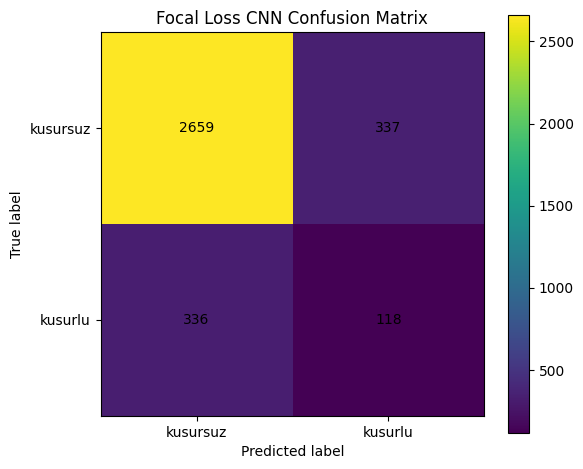

Confusion matrix grafiği kaydedildi:
/content/drive/MyDrive/DERİNMODEL/03_ciktilar/grafikler/3_kendi_cnn_modeli/3_kendi_cnn_modeli/dagm_2007_focal_cnn_confusion_matrix.png


In [29]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Gerçek etiketler
y_true_focal = np.array(test_labels_3)

# Tahmin olasılıkları
y_prob_focal = best_focal_model.predict(test_dataset_3).ravel()

# 0.50 threshold ile tahmin
y_pred_focal = (y_prob_focal >= 0.50).astype(int)

print("Gerçek etiket sayısı:", len(y_true_focal))
print("Tahmin sayısı:", len(y_pred_focal))

cm_focal = confusion_matrix(y_true_focal, y_pred_focal)

print("Confusion Matrix:")
print(cm_focal)

report_focal = classification_report(
    y_true_focal,
    y_pred_focal,
    target_names=["kusursuz", "kusurlu"],
    output_dict=True
)

report_focal_df = pd.DataFrame(report_focal).transpose()

focal_report_path = TABLE_DIR / "dagm_2007_focal_cnn_classification_report.csv"
report_focal_df.to_csv(focal_report_path)

print("Classification report kaydedildi:")
print(focal_report_path)

display(report_focal_df)

plt.figure(figsize=(6, 5))
plt.imshow(cm_focal)
plt.title("Focal Loss CNN Confusion Matrix")
plt.colorbar()

classes = ["kusursuz", "kusurlu"]
plt.xticks(np.arange(len(classes)), classes)
plt.yticks(np.arange(len(classes)), classes)

for i in range(cm_focal.shape[0]):
    for j in range(cm_focal.shape[1]):
        plt.text(j, i, cm_focal[i, j], ha="center", va="center")

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()

focal_cm_path = GRAPH_DIR / "3_kendi_cnn_modeli" / "dagm_2007_focal_cnn_confusion_matrix.png"
focal_cm_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(focal_cm_path, dpi=300)
plt.show()

print("Confusion matrix grafiği kaydedildi:")
print(focal_cm_path)

In [30]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix
import pandas as pd
import numpy as np

threshold_values = np.arange(0.05, 1.00, 0.05)

focal_threshold_records = []

for threshold in threshold_values:
    y_pred_thr = (y_prob_focal >= threshold).astype(int)

    acc = accuracy_score(y_true_focal, y_pred_thr)
    precision = precision_score(y_true_focal, y_pred_thr, zero_division=0)
    recall = recall_score(y_true_focal, y_pred_thr, zero_division=0)
    f1 = f1_score(y_true_focal, y_pred_thr, zero_division=0)

    cm = confusion_matrix(y_true_focal, y_pred_thr)
    tn, fp, fn, tp = cm.ravel()

    focal_threshold_records.append({
        "threshold": round(float(threshold), 2),
        "accuracy": acc,
        "kusurlu_precision": precision,
        "kusurlu_recall": recall,
        "kusurlu_f1": f1,
        "true_negative": tn,
        "false_positive": fp,
        "false_negative": fn,
        "true_positive": tp
    })

focal_threshold_df = pd.DataFrame(focal_threshold_records)

focal_threshold_path = TABLE_DIR / "dagm_2007_focal_cnn_threshold_analizi.csv"
focal_threshold_df.to_csv(focal_threshold_path, index=False)

print("Focal CNN threshold analizi kaydedildi:")
print(focal_threshold_path)

display(focal_threshold_df)

Focal CNN threshold analizi kaydedildi:
/content/drive/MyDrive/DERİNMODEL/03_ciktilar/tablolar/dagm_2007_focal_cnn_threshold_analizi.csv


,threshold,accuracy,kusurlu_precision,kusurlu_recall,kusurlu_f1,true_negative,false_positive,false_negative,true_positive
0,0.05,0.131594,0.131594,1.000000,0.232582,0,2996,0,454
1,0.10,0.131594,0.131594,1.000000,0.232582,0,2996,0,454
2,0.15,0.131594,0.131594,1.000000,0.232582,0,2996,0,454
3,0.20,0.257101,0.150481,1.000000,0.261596,433,2563,0,454
4,0.25,0.278841,0.154317,1.000000,0.267373,508,2488,0,454
5,0.30,0.279420,0.154187,0.997797,0.267099,511,2485,1,453
6,0.35,0.348696,0.157955,0.911894,0.269268,789,2207,40,414
7,0.40,0.493913,0.167010,0.713656,0.270677,1380,1616,130,324
8,0.45,0.792174,0.258716,0.310573,0.282282,2592,404,313,141
9,0.50,0.804928,0.259341,0.259912,0.259626,2659,337,336,118


Seçilen threshold: 0.4
Confusion Matrix:
[[1380 1616]
 [ 130  324]]
0.40 threshold classification report kaydedildi:
/content/drive/MyDrive/DERİNMODEL/03_ciktilar/tablolar/dagm_2007_focal_cnn_threshold_040_classification_report.csv


,precision,recall,f1-score,support
kusursuz,0.913907,0.460614,0.612517,2996.000000
kusurlu,0.167010,0.713656,0.270677,454.000000
accuracy,0.493913,0.493913,0.493913,0.493913
macro avg,0.540459,0.587135,0.441597,3450.000000
weighted avg,0.815620,0.493913,0.567532,3450.000000


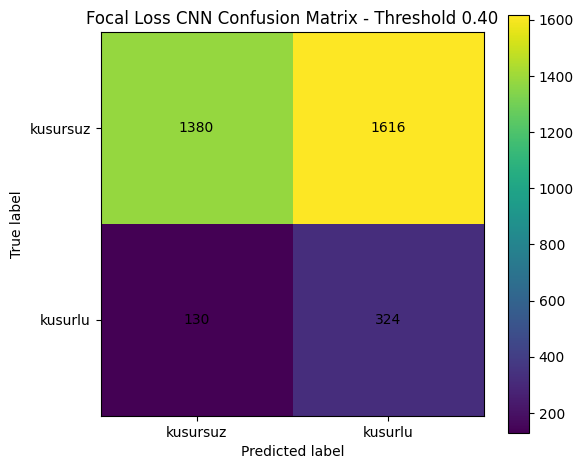

0.40 threshold confusion matrix grafiği kaydedildi:
/content/drive/MyDrive/DERİNMODEL/03_ciktilar/grafikler/3_kendi_cnn_modeli/3_kendi_cnn_modeli/dagm_2007_focal_cnn_threshold_040_confusion_matrix.png


In [31]:
SELECTED_THRESHOLD = 0.40

y_pred_focal_selected = (y_prob_focal >= SELECTED_THRESHOLD).astype(int)

cm_focal_selected = confusion_matrix(y_true_focal, y_pred_focal_selected)

print("Seçilen threshold:", SELECTED_THRESHOLD)
print("Confusion Matrix:")
print(cm_focal_selected)

report_focal_selected = classification_report(
    y_true_focal,
    y_pred_focal_selected,
    target_names=["kusursuz", "kusurlu"],
    output_dict=True
)

report_focal_selected_df = pd.DataFrame(report_focal_selected).transpose()

selected_report_path = TABLE_DIR / "dagm_2007_focal_cnn_threshold_040_classification_report.csv"
report_focal_selected_df.to_csv(selected_report_path)

print("0.40 threshold classification report kaydedildi:")
print(selected_report_path)

display(report_focal_selected_df)

plt.figure(figsize=(6, 5))
plt.imshow(cm_focal_selected)
plt.title("Focal Loss CNN Confusion Matrix - Threshold 0.40")
plt.colorbar()

classes = ["kusursuz", "kusurlu"]
plt.xticks(np.arange(len(classes)), classes)
plt.yticks(np.arange(len(classes)), classes)

for i in range(cm_focal_selected.shape[0]):
    for j in range(cm_focal_selected.shape[1]):
        plt.text(j, i, cm_focal_selected[i, j], ha="center", va="center")

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()

selected_cm_path = GRAPH_DIR / "3_kendi_cnn_modeli" / "dagm_2007_focal_cnn_threshold_040_confusion_matrix.png"
selected_cm_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(selected_cm_path, dpi=300)
plt.show()

print("0.40 threshold confusion matrix grafiği kaydedildi:")
print(selected_cm_path)

In [32]:
model_comparison_records = [
    {
        "model": "Model 1 - Regularized CNN",
        "strateji": "128x128, class_weight, L2, Dropout, EarlyStopping",
        "threshold": 0.50,
        "accuracy": 0.8661,
        "kusurlu_precision": 0.4718,
        "kusurlu_recall": 0.1476,
        "kusurlu_f1": 0.2248,
        "yorum": "Accuracy yüksek görünse de kusurlu sınıfı büyük oranda kaçırdı."
    },
    {
        "model": "Model 2 - Balanced CNN",
        "strateji": "128x128, dengeli batch/sampling, threshold analizi",
        "threshold": 0.50,
        "accuracy": 0.8843,
        "kusurlu_precision": 0.8985,
        "kusurlu_recall": 0.1366,
        "kusurlu_f1": 0.2371,
        "yorum": "Precision yüksek fakat kusurlu recall çok düşük kaldı."
    },
    {
        "model": "Model 3 - Focal Loss CNN",
        "strateji": "256x256, focal loss, PR-AUC takibi, threshold 0.40",
        "threshold": 0.40,
        "accuracy": 0.4939,
        "kusurlu_precision": 0.1670,
        "kusurlu_recall": 0.7137,
        "kusurlu_f1": 0.2707,
        "yorum": "Kusurlu yakalama başarısı belirgin arttı; yanlış pozitif sayısı yüksektir."
    }
]

model_comparison_df = pd.DataFrame(model_comparison_records)

comparison_path = TABLE_DIR / "dagm_2007_kendi_cnn_model_karsilastirma.csv"
model_comparison_df.to_csv(comparison_path, index=False)

print("Kendi CNN model karşılaştırma tablosu kaydedildi:")
print(comparison_path)

display(model_comparison_df)

Kendi CNN model karşılaştırma tablosu kaydedildi:
/content/drive/MyDrive/DERİNMODEL/03_ciktilar/tablolar/dagm_2007_kendi_cnn_model_karsilastirma.csv


,model,strateji,threshold,accuracy,kusurlu_precision,kusurlu_recall,kusurlu_f1,yorum
0,Model 1 - Regularized CNN,"128x128, class_weight, L2, Dropout, EarlyStopping",0.5,0.8661,0.4718,0.1476,0.2248,Accuracy yüksek görünse de kusurlu sınıfı büyü...
1,Model 2 - Balanced CNN,"128x128, dengeli batch/sampling, threshold ana...",0.5,0.8843,0.8985,0.1366,0.2371,Precision yüksek fakat kusurlu recall çok düşü...
2,Model 3 - Focal Loss CNN,"256x256, focal loss, PR-AUC takibi, threshold ...",0.4,0.4939,0.1670,0.7137,0.2707,Kusurlu yakalama başarısı belirgin arttı; yanl...


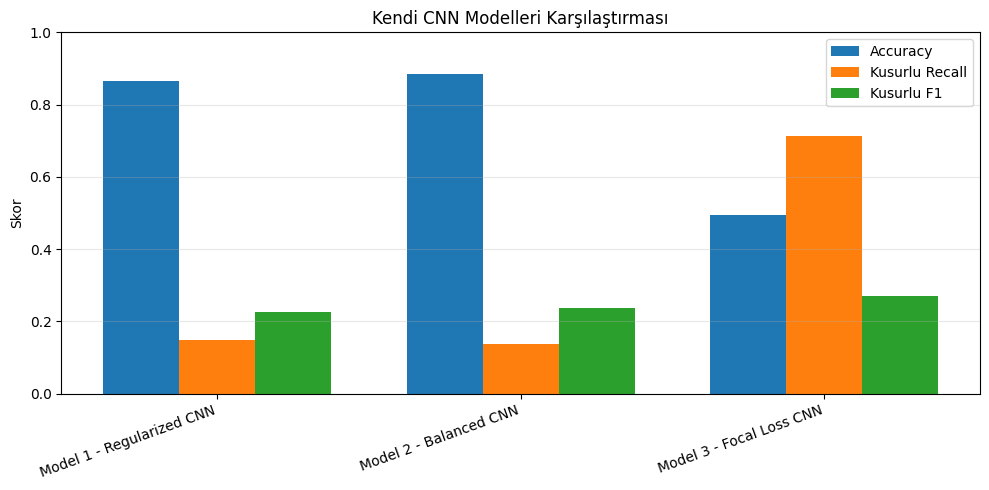

Kendi CNN model karşılaştırma grafiği kaydedildi:
/content/drive/MyDrive/DERİNMODEL/03_ciktilar/grafikler/3_kendi_cnn_modeli/3_kendi_cnn_modeli/dagm_2007_kendi_cnn_model_karsilastirma.png


In [33]:
plt.figure(figsize=(10, 5))

x = np.arange(len(model_comparison_df))
width = 0.25

plt.bar(x - width, model_comparison_df["accuracy"], width, label="Accuracy")
plt.bar(x, model_comparison_df["kusurlu_recall"], width, label="Kusurlu Recall")
plt.bar(x + width, model_comparison_df["kusurlu_f1"], width, label="Kusurlu F1")

plt.xticks(x, model_comparison_df["model"], rotation=20, ha="right")
plt.ylabel("Skor")
plt.title("Kendi CNN Modelleri Karşılaştırması")
plt.ylim(0, 1)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

comparison_graph_path = GRAPH_DIR / "3_kendi_cnn_modeli" / "dagm_2007_kendi_cnn_model_karsilastirma.png"
comparison_graph_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(comparison_graph_path, dpi=300)
plt.show()

print("Kendi CNN model karşılaştırma grafiği kaydedildi:")
print(comparison_graph_path)